# CHES-related analysis

This notebook is dedicated to the processing and analysis of trends of the CHES variables. 
Focus identities and related variables: 
- LRGEN and LRECON: general left-right positioning, economic left-right positioning
- Families: The ideologies that the parties subscribe to
- GAL-TAN: Positioning of political parties according to the libertarian - traditional axis. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px

In [2]:
df = pd.read_csv("../Datasets/CHES-SI.tsv", sep="\t", encoding="utf-8")
cols = ["parlamint", "party_id", "party", "year", "lrgen", "lrecon", "galtan", "family"]
df = df[cols]
print(df.shape)
df.head()

(49, 8)


,parlamint,party_id,party,year,lrgen,lrecon,galtan,family
0,-,2909,AS,2006,4.6,3.8,2.6,7
1,-,2904,SLS-SMS,2010,6.8,5.3,7.8,4
2,DL,-,-,-,-,-,-,-
3,DLGV,-,-,-,-,-,-,-
4,DeSUS,2906,DeSUS,2002,3.4,3.4,5.8,9


In [3]:
#Parties in ParlaMint, but not in CHES: DL, DLGV, GAS, Konkretno, Lipa, NP, NeP
df = df[df["parlamint"]!="-"]
df = df[df["lrgen"] != "-"]

df.shape

(40, 8)

In [4]:
mapping={
    "1":"Radical Right", 
    "2":"Conservatives",
    "3":"Liberal", 
    "4":"Christian-Democratic",
    "5":"Socialist", 
    "6":"Radical Left", 
    "7":"Green", 
    "8":"Regionalist", 
    "9":"No family", 
    "10":"Confessional", 
    "11":"Agrarian/Center"
}

groups = {
    "ZL": "ZL/Levica",
    "Levica + ZL":"ZL/Levica",
    "Levica": "ZL/Levica",
    "AB":"ZaAB/ZaSLD/SAB",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL",
    "SMC":"SMC/GAS/Konkretno",
    "Konkretno": "SMC/GAS/Konkretno"
}
df["family"] = df["family"].map(mapping).fillna(df["family"])
df["grouped_parties"] = df['parlamint'].replace(groups).fillna(df['parlamint'])

df.head()

,parlamint,party_id,party,year,lrgen,lrecon,galtan,family,grouped_parties
4,DeSUS,2906,DeSUS,2002,3.4,3.4,5.8,No family,DeSUS
5,DeSUS,2906,DeSUS,2006,3.2,2.6,4.5,No family,DeSUS
6,DeSUS,2906,DeSUS,2010,4.2,3.3,5.2,No family,DeSUS
7,DeSUS,2906,DeSUS,2014,4.2,4.0,5.3,No family,DeSUS
8,DeSUS,2906,DeSUS,2019,3.8,3.3,5.1,No family,DeSUS


# Distributions

### Family
(CHES Codebook definition) "FAMILY= classification was initially based on Hix and Lord (1997), except that we place confessional and agrarian parties in separate categories. Family association for parties in Central/Eastern Europe was based initially on Derksen classification (now incorporated in Wikipedia), triangulated by a) membership or aﬃliation with international and EU party associations, and b) self-identification. We update family codings based on ideological shifts or organizational changes."

In [5]:
#Check families
family_cols = ["parlamint", "party", "year", "family"]
family = df[family_cols]

family = family.sort_values(by=["parlamint", "year"])
family["family_change"] = family.groupby("parlamint")["family"].transform(lambda x: x != x.iloc[0])
changes = family[family["family_change"] != False]

print("Parties with family changes:")
print(changes)
#No changes in the Family during the years


Parties with family changes:
Empty DataFrame
Columns: [parlamint, party, year, family, family_change]
Index: []


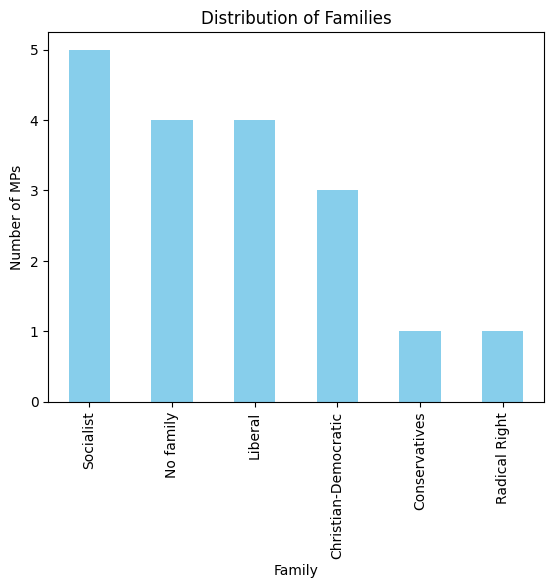

In [6]:
family = family.drop_duplicates(subset="parlamint").reset_index(drop=True)
family_counts = family["family"].value_counts()
family_counts.plot(kind='bar', color="skyblue")
plt.xlabel('Family')
plt.ylabel('Number of MPs')
plt.title('Distribution of Families')
plt.show()

In [7]:
col = ["parlamint", "family"]
family = family[col]
party_family = family.sort_values('parlamint')

#latex_table = party_family.to_latex(index=False)
#print(latex_table)


## Left-right political positioning
LRGEN= position of the party in YEAR in terms of its overall ideological stance.
0 = Extreme left .. 5 = Center.. 10 = Extreme right

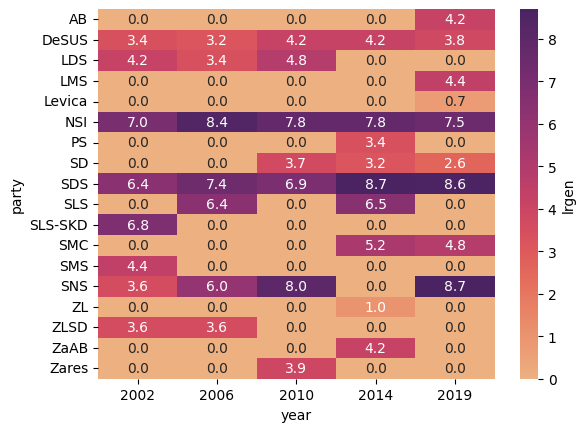

In [8]:
lrgen_pivot = df.pivot(index="party", columns="year", values="lrgen").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="flare", cbar_kws={'label': 'lrgen'}
)
plt.show()

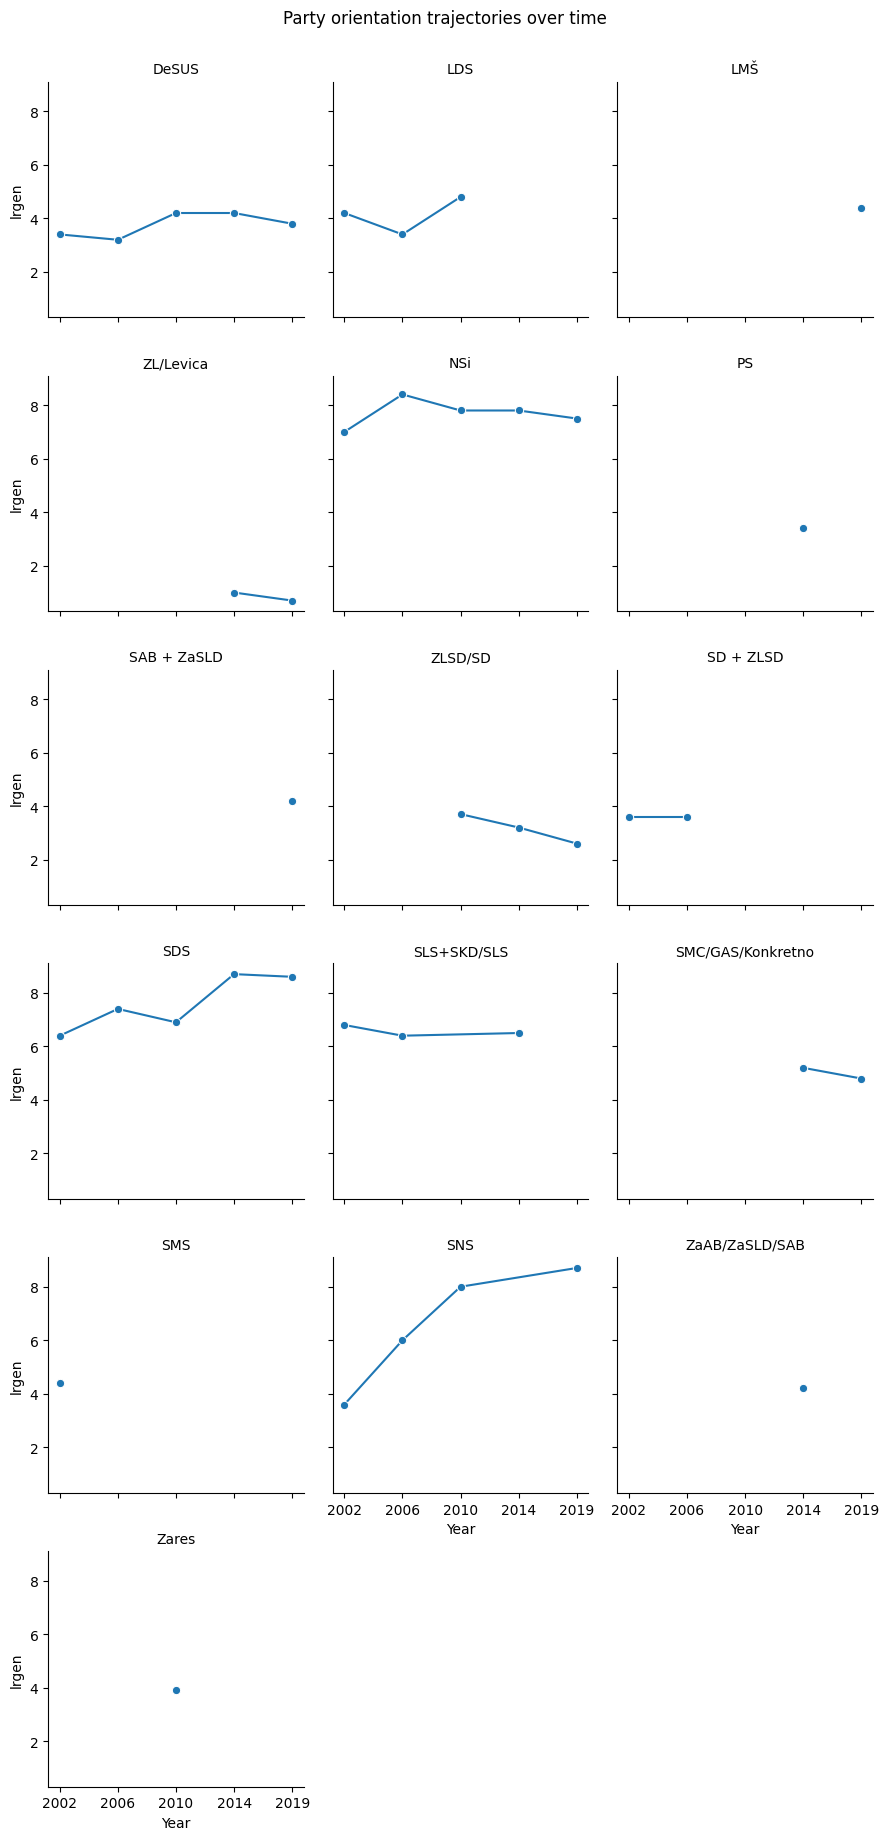

In [9]:
import numpy as np
df["lrgen"] = pd.to_numeric(df["lrgen"])
g = sns.FacetGrid(df, col="grouped_parties", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party orientation trajectories over time", y=1.02)

plt.show()

In [10]:
#Selection of most interesting patterns for Chapter III: 
select = ["SNS", "ZL/Levica", "SDS", "NSi"]
lrgen_select = df[df["grouped_parties"].isin(select)].sort_values(by=["grouped_parties","year"]).reset_index(drop=True)
lrgen_select



,parlamint,party_id,party,year,lrgen,lrecon,galtan,family,grouped_parties
0,NSi,2905,NSI,2002,7.0,4.8,7.8,Christian-Democratic,NSi
1,NSi,2905,NSI,2006,8.4,6.8,8.8,Christian-Democratic,NSi
2,NSi,2905,NSI,2010,7.8,6.3,9.3,Christian-Democratic,NSi
3,NSi,2905,NSI,2014,7.8,8.1,8.3,Christian-Democratic,NSi
4,NSi,2905,NSI,2019,7.5,7.4,8,Christian-Democratic,NSi
5,SDS,2902,SDS,2002,6.4,4.8,5.8,Conservatives,SDS
6,SDS,2902,SDS,2006,7.4,6.4,7.4,Conservatives,SDS
7,SDS,2902,SDS,2010,6.9,5.9,7.8,Conservatives,SDS
8,SDS,2902,SDS,2014,8.7,8.6,8.4,Conservatives,SDS
9,SDS,2902,SDS,2019,8.6,7.5,8.7,Conservatives,SDS


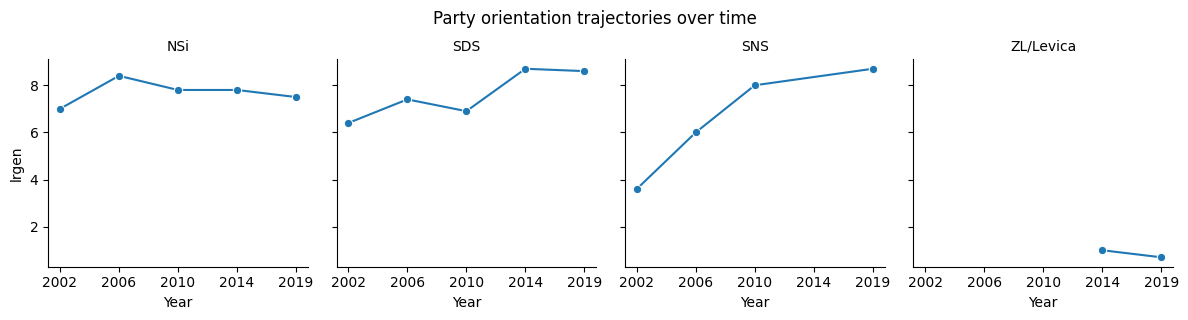

In [11]:
g = sns.FacetGrid(lrgen_select, col="grouped_parties", col_wrap=4, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.figure.suptitle("Party orientation trajectories over time", y=1.05)

plt.show()